In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm
import re
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score 
import lightgbm as lgb
import pickle

In [2]:
df = pd.read_csv('../train_csv/train.csv',index_col=0)
rank_map = {1:6,2:5,3:4,4:3,5:2,6:1}
rank_mod_map = {1:6,2:5,3:4,4:0,5:0,6:0}
df_y = df['着'].map(rank_mod_map).astype(int)
df_x = df.drop(['選手名','着','展示'],axis=1)
x_train, x_vali, y_train, y_vali = train_test_split(df_x, df_y, test_size=0.2, shuffle=False)

train_group = x_train['RaceID'].value_counts(sort = False)
val_group = x_vali['RaceID'].value_counts(sort = False)

odds_train = x_train[['RaceID','3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻']]
odds_vali = x_vali[['RaceID','3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻']]

x_train_o = x_train.drop(['3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻'], axis=1)
x_train = x_train.drop(['RaceID','3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻'], axis=1)
x_vali_o = x_vali.drop(['3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻'], axis=1)
x_vali = x_vali.drop(['RaceID','3連単_結果', '3連単_払戻', '3連複_結果', '3連複_払戻', '2連単_結果', '2連単_払戻', '2連複_結果', '2連複_払戻'], axis=1)

/var/folders/39/lzc02mxx3d1bksjxyqbhgv9c0000gn/T/ipykernel_59638/2116389541.py:1: DtypeWarning: Columns (20,24,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../train_csv/train.csv',index_col=0)


In [3]:
lgbm_params =  {
    'task': 'train',
    'boosting_type': 'gbdt',
    'objective': 'lambdarank', #←ここでランキング学習と指定！
    'metric': 'ndcg',   # for lambdarank
    'ndcg_eval_at': [1,2,3],  # 3連単を予測したい
    'max_position': 6,  # 競艇は6位までしかない
    'learning_rate': 0.01, 
    'group_column': 13,
    'min_data': 1,
    'min_data_in_bin': 1,
    'random_state': 777,
    #'num_leaves': 31,
   #'max_depth':35,
}

lgtrain = lgb.Dataset(x_train, y_train,  group=train_group)
lgvalid = lgb.Dataset(x_vali, y_vali,group=val_group)

lgb_clf = lgb.train(
    lgbm_params,
    lgtrain,
    num_boost_round=10000,
    valid_sets=[lgtrain, lgvalid],
    valid_names=['train','valid'],
    early_stopping_rounds=1000,
    verbose_eval=100
)

/Users/tojo/Documents/boat/.boat_env/lib/python3.10/site-packages/lightgbm/engine.py:181: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
/Users/tojo/Documents/boat/.boat_env/lib/python3.10/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[LightGBM] [Warning] Unknown parameter: max_position
[LightGBM] [Warning] Unknown parameter: max_position
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.233827 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1937
[LightGBM] [Info] Number of data points in the train set: 572084, number of used features: 14
[LightGBM] [Warning] Unknown parameter: max_position
Training until validation scores don't improve for 1000 rounds
[100]	train's ndcg@1: 0.682099	train's ndcg@2: 0.704542	train's ndcg@3: 0.742445	valid's ndcg@1: 0.683238	valid's ndcg@2: 0.704681	valid's ndcg@3: 0.74116
[200]	train's ndcg@1: 0.685075	train's ndcg@2: 0.708174	train's ndcg@3: 0.745356	valid's ndcg@1: 0.684739	valid's ndcg@2: 0.706852	valid's ndcg@3: 0.743323
[300]	train's ndcg@1: 0.687376	train's ndcg@2: 0.709962	train's ndcg@3: 0.7471	valid's ndcg@1: 0.686416	valid's ndcg@2: 0.707958	valid's ndcg@3: 0.744161
[400]	train's ndcg@1

In [4]:
with open('../model/lgb_clf_tenji_nasi.pickle', 'wb') as f:
    pickle.dump(lgb_clf, f)

In [5]:
y_pred_model = lgb_clf.predict(x_vali ,num_iteration=lgb_clf.best_iteration)

In [6]:
raceid = odds_vali['RaceID'].value_counts(sort =False).index
odds_vali_r = pd.DataFrame([],columns = odds_vali.columns)
for i,r in tqdm(enumerate(raceid)):
    o = odds_vali[odds_vali['RaceID'] == r][0:1]
    odds_vali_r = pd.concat([odds_vali_r, o])

24200it [03:55, 102.77it/s]


In [7]:
odds_vali_r

,RaceID,3連単_結果,3連単_払戻,3連複_結果,3連複_払戻,2連単_結果,2連単_払戻,2連複_結果,2連複_払戻
572084,2020-12-27-02-06,3-1-2,4600,1-2-3,1400,3-1,860,1-3,520
572089,2020-12-27-02-07,1-3-6,3980,1-3-6,2420,1-3,490,1-3,430
572095,2020-12-27-02-08,3-2-6,2440,2-3-6,490,3-2,1490,2-3,880
572101,2020-12-27-02-09,1-4-6,3200,1-4-6,1290,1-4,1270,1-4,710
572107,2020-12-27-02-10,1-5-6,4910,1-5-6,2630,1-5,1260,1-5,1590
...,...,...,...,...,...,...,...,...,...
715077,2021-01-13-01-08,1-5-6,600,1-5-6,350,1-5,190,1-5,180
715083,2021-01-13-01-09,1-4-5,7450,1-4-5,3210,1-4,1480,1-4,1360
715089,2021-01-13-01-10,2-3-1,7210,1-2-3,240,2-3,5170,2-3,1960
715095,2021-01-13-01-11,1-4-3,1480,1-3-4,660,1-4,530,1-4,440


In [8]:
def cal(y_vali,y_pred_model ,val_group, odds_vali_r):
    #Validデータ的中率の算出
    j = 0
    m = -1

    solo_count = 0
    solo_prize = []

    doub_count = 0
    doub_prize = []

    tri_count = 0
    tri_prize = []

    trio_count = 0
    trio_prize = []

    odds_vali_r = odds_vali_r.astype(str)


    for i in tqdm(val_group):
        result = y_pred_model[j:j+i] #グループでの順位
        ans = y_vali.iloc[j:j+i].reset_index() #答え
        result1st = np.argmax(result) #予測の1位

        m = m + 1

        if len(np.where(result==sorted(result)[::-1][0])[0])>1:
            result2nd = np.where(result==sorted(result)[::-1][1])[0][0]
            result3rd = np.where(result==sorted(result)[::-1][1])[0][1]
        else:
            if i > 1:
                result2nd = np.where(result==sorted(result)[::-1][1])[0][0]
            if i > 2:
                result3rd = np.where(result==sorted(result)[::-1][2])[0][0]
        
        #print(int(ans[ans["着"] == ans.max()[1]].index.values))
        ans1st = int(ans[ans["着"]==ans.max()[1]].index.values)
        and_sort = ans.sort_values("着",ascending=False)['着']
        if i > 2:
            a2n = int(and_sort[1])
            a3n = int(and_sort[2])
            
            if len(ans[ans["着"]==a2n].index.values)>1:
                ans2nd = int(ans[ans["着"]==a2n].index.values[0])
                ans3rd = int(ans[ans["着"]==a2n].index.values[1])
            else:
                if i > 1:
                    ans2nd = int(ans[ans["着"]==a2n].index.values[0])
                if i > 2:
                    ans3rd = int(ans[ans["着"]==a3n].index.values[0])
        
        if ans1st==result1st:
            #print(ans1st,result1st)
            solo_count = solo_count+1

        if i > 1:
            if (ans1st==result1st)&(ans2nd==result2nd):
                doub_count = doub_count+1
                if str.isdecimal(odds_vali_r.loc[:,'2連単_払戻'].iat[m]):
                    doub_prize.append(int(odds_vali_r.loc[:,'2連単_払戻'].iat[m]))

        if i > 2:
            if (ans1st==result1st)&(ans2nd==result2nd)&(ans3rd==result3rd):
                tri_count = tri_count+1 
                if str.isdecimal(odds_vali_r.loc[:,'3連単_払戻'].iat[m]):
                    tri_prize.append(int(odds_vali_r.loc[:,'3連単_払戻'].iat[m]))
        
        if i > 2:
            ans_set = set([ans1st, ans2nd, ans3rd])
            res_set = set([result1st, result2nd,result3rd])
            if ans_set == res_set:
                trio_count = trio_count+1
                if str.isdecimal(odds_vali_r.loc[:,'3連複_払戻'].iat[m]):
                    trio_prize.append(int(odds_vali_r.loc[:,'3連複_払戻'].iat[m]))
        j = j + i
    
    return solo_count, doub_count, doub_prize, tri_count, tri_prize, trio_count, trio_prize, len(val_group)

def sum(list):
    sum = 0
    for i in list:
        sum = sum + i
    return sum


In [41]:
v = val_group.head(200)

In [ ]:
solo_count, doub_count, doub_prize, tri_count, tri_prize, trio_count, trio_prize = cal(y_vali,y_pred_model,val_group, odds_vali_r)

In [42]:
solo_count, doub_count, doub_prize, tri_count, tri_prize, trio_count, trio_prize, count = cal(y_vali,y_pred_model,v, odds_vali_r)

100%|██████████| 200/200 [00:01<00:00, 132.47it/s]


In [43]:
f = open('BP_nasi.txt', 'w')

print('--------------------------',file = f)
print('購入金額', count*100,'円',file = f)
print('--------------------------',file = f)
print('単勝',file = f)
print("的中率：",round(solo_count/count*100,2),"%",file = f)
print('--------------------------',file = f)
print('2連単',file = f)
print("的中率：",round(doub_count/count*100,2),"%",file = f)
print("払戻金額-購入金額：",round(sum(doub_prize) - (count*100),2),"円",file = f)
print("回収率：",round((sum(doub_prize) / (count*100) *100) ,2),"%",file = f)
print('--------------------------',file = f)
print('3連単',file = f)
print("的中率：",round(tri_count/count*100,2),"%",file = f)
print("払戻金額-購入金額：",round(sum(tri_prize) - (count*100),2),"円",file = f)
print("回収率：",round((sum(tri_prize) / (count*100)*100),2),"%",file = f)
print('--------------------------',file = f)
print('3連複',file = f)
print("的中率：",round(trio_count/count*100,2),"%",file = f)
print("払戻金額-購入金額：",round(sum(trio_prize) - (count*100),2),"円",file = f)
print("回収率：",round((sum(trio_prize) / (count*100)*100),2),"%",file = f)
print('--------------------------',file = f)

f.close()

In [39]:
def info(df,name):
    print(name)
    print("最大", " : ", max(df))
    print('平均', " : ", round(sum(df)/len(df)))
    plt.hist(df,bins = 30, log=True)
    plt.xlabel('prize (yen)')
    plt.ylabel('count')
    plt.grid()
    plt.title(name)
    plt.show()

double
最大  :  7180
平均  :  769


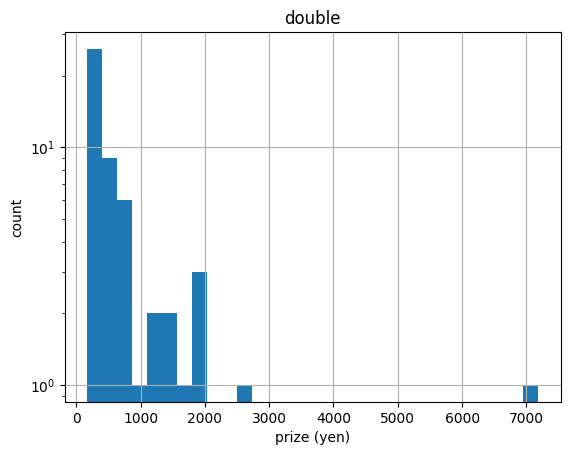

In [44]:
info(doub_prize, "double")

In [ ]:
info(tri_prize, "tri")

tri


ValueError: max() arg is an empty sequence

trio
最大  :  10830
平均  :  1496


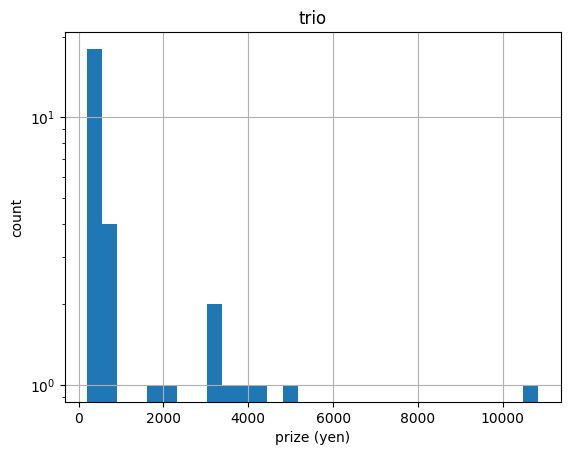

In [ ]:
info(trio_prize, "trio")